# Two-Site Binding Model: Association and Dissociation

This notebook simulates surface response traces for a ligand **P** with two equivalent, independent binding sites.

The analyte **L** binds sequentially:

- P + L ⇌ PL  (singly-bound)
- PL + L ⇌ LPL  (doubly-bound)

Both bound states contribute to the measured signal via `Rmax_PL` and `Rmax_LPL`.

In [ ]:
import numpy as np
from pykingenie.utils.signal_surface import (
    solve_two_site_association,
    solve_two_site_dissociation
)
from pykingenie.utils.plotting import plot_traces
from pykingenie.utils.palettes import VIRIDIS
from notebook_helpers import show_plotly_static

## Parameters

- `kon`: intrinsic association rate constant per site (1/μM/s)
- `koff`: intrinsic dissociation rate constant per site (1/s)
- `Rmax_PL`: maximum signal contribution of the singly-bound complex (PL)
- `Rmax_LPL`: maximum signal contribution of the doubly-bound complex (LPL)

Analyte concentrations are log-spaced and traces use a Viridis palette.

In [ ]:
kon = 0.5
koff = 0.01

Rmax_PL  = 0.5
Rmax_LPL = 1.0

In [8]:
concentrations = np.logspace(-2, 1, 6)  # In μM
t_assoc = np.linspace(0, 300, 400)
t_disso = np.linspace(0, 300, 400)

colors = [VIRIDIS[int(i)] for i in np.linspace(0, len(VIRIDIS) - 1, len(concentrations))]

In [ ]:
combined_xs, combined_ys, legends = [], [], []

for conc in concentrations:
    assoc_matrix = solve_two_site_association(
        time=t_assoc,
        a_conc=conc,
        kon=kon,
        koff=koff,
        Rmax_PL=Rmax_PL,
        Rmax_LPL=Rmax_LPL,
        fPL_0=0,
        fLPL_0=0,
    )

    # assoc_matrix columns: total_signal, signal_PL, signal_LPL
    y_assoc = assoc_matrix[:, 0]

    # Convert end-of-association signals back to fractions for dissociation initial conditions
    fPL_end  = assoc_matrix[-1, 1] / Rmax_PL  if Rmax_PL  else 0
    fLPL_end = assoc_matrix[-1, 2] / Rmax_LPL if Rmax_LPL else 0

    disso_matrix = solve_two_site_dissociation(
        time=t_disso,
        koff=koff,
        Rmax_PL=Rmax_PL,
        Rmax_LPL=Rmax_LPL,
        fPL_0=fPL_end,
        fLPL_0=fLPL_end,
    )

    y_disso = disso_matrix[:, 0]

    combined_xs.append([t_assoc, t_disso + t_assoc[-1]])
    combined_ys.append([y_assoc, y_disso])
    legends.append(f"{conc:.3g} μM")

show = [True] * len(concentrations)

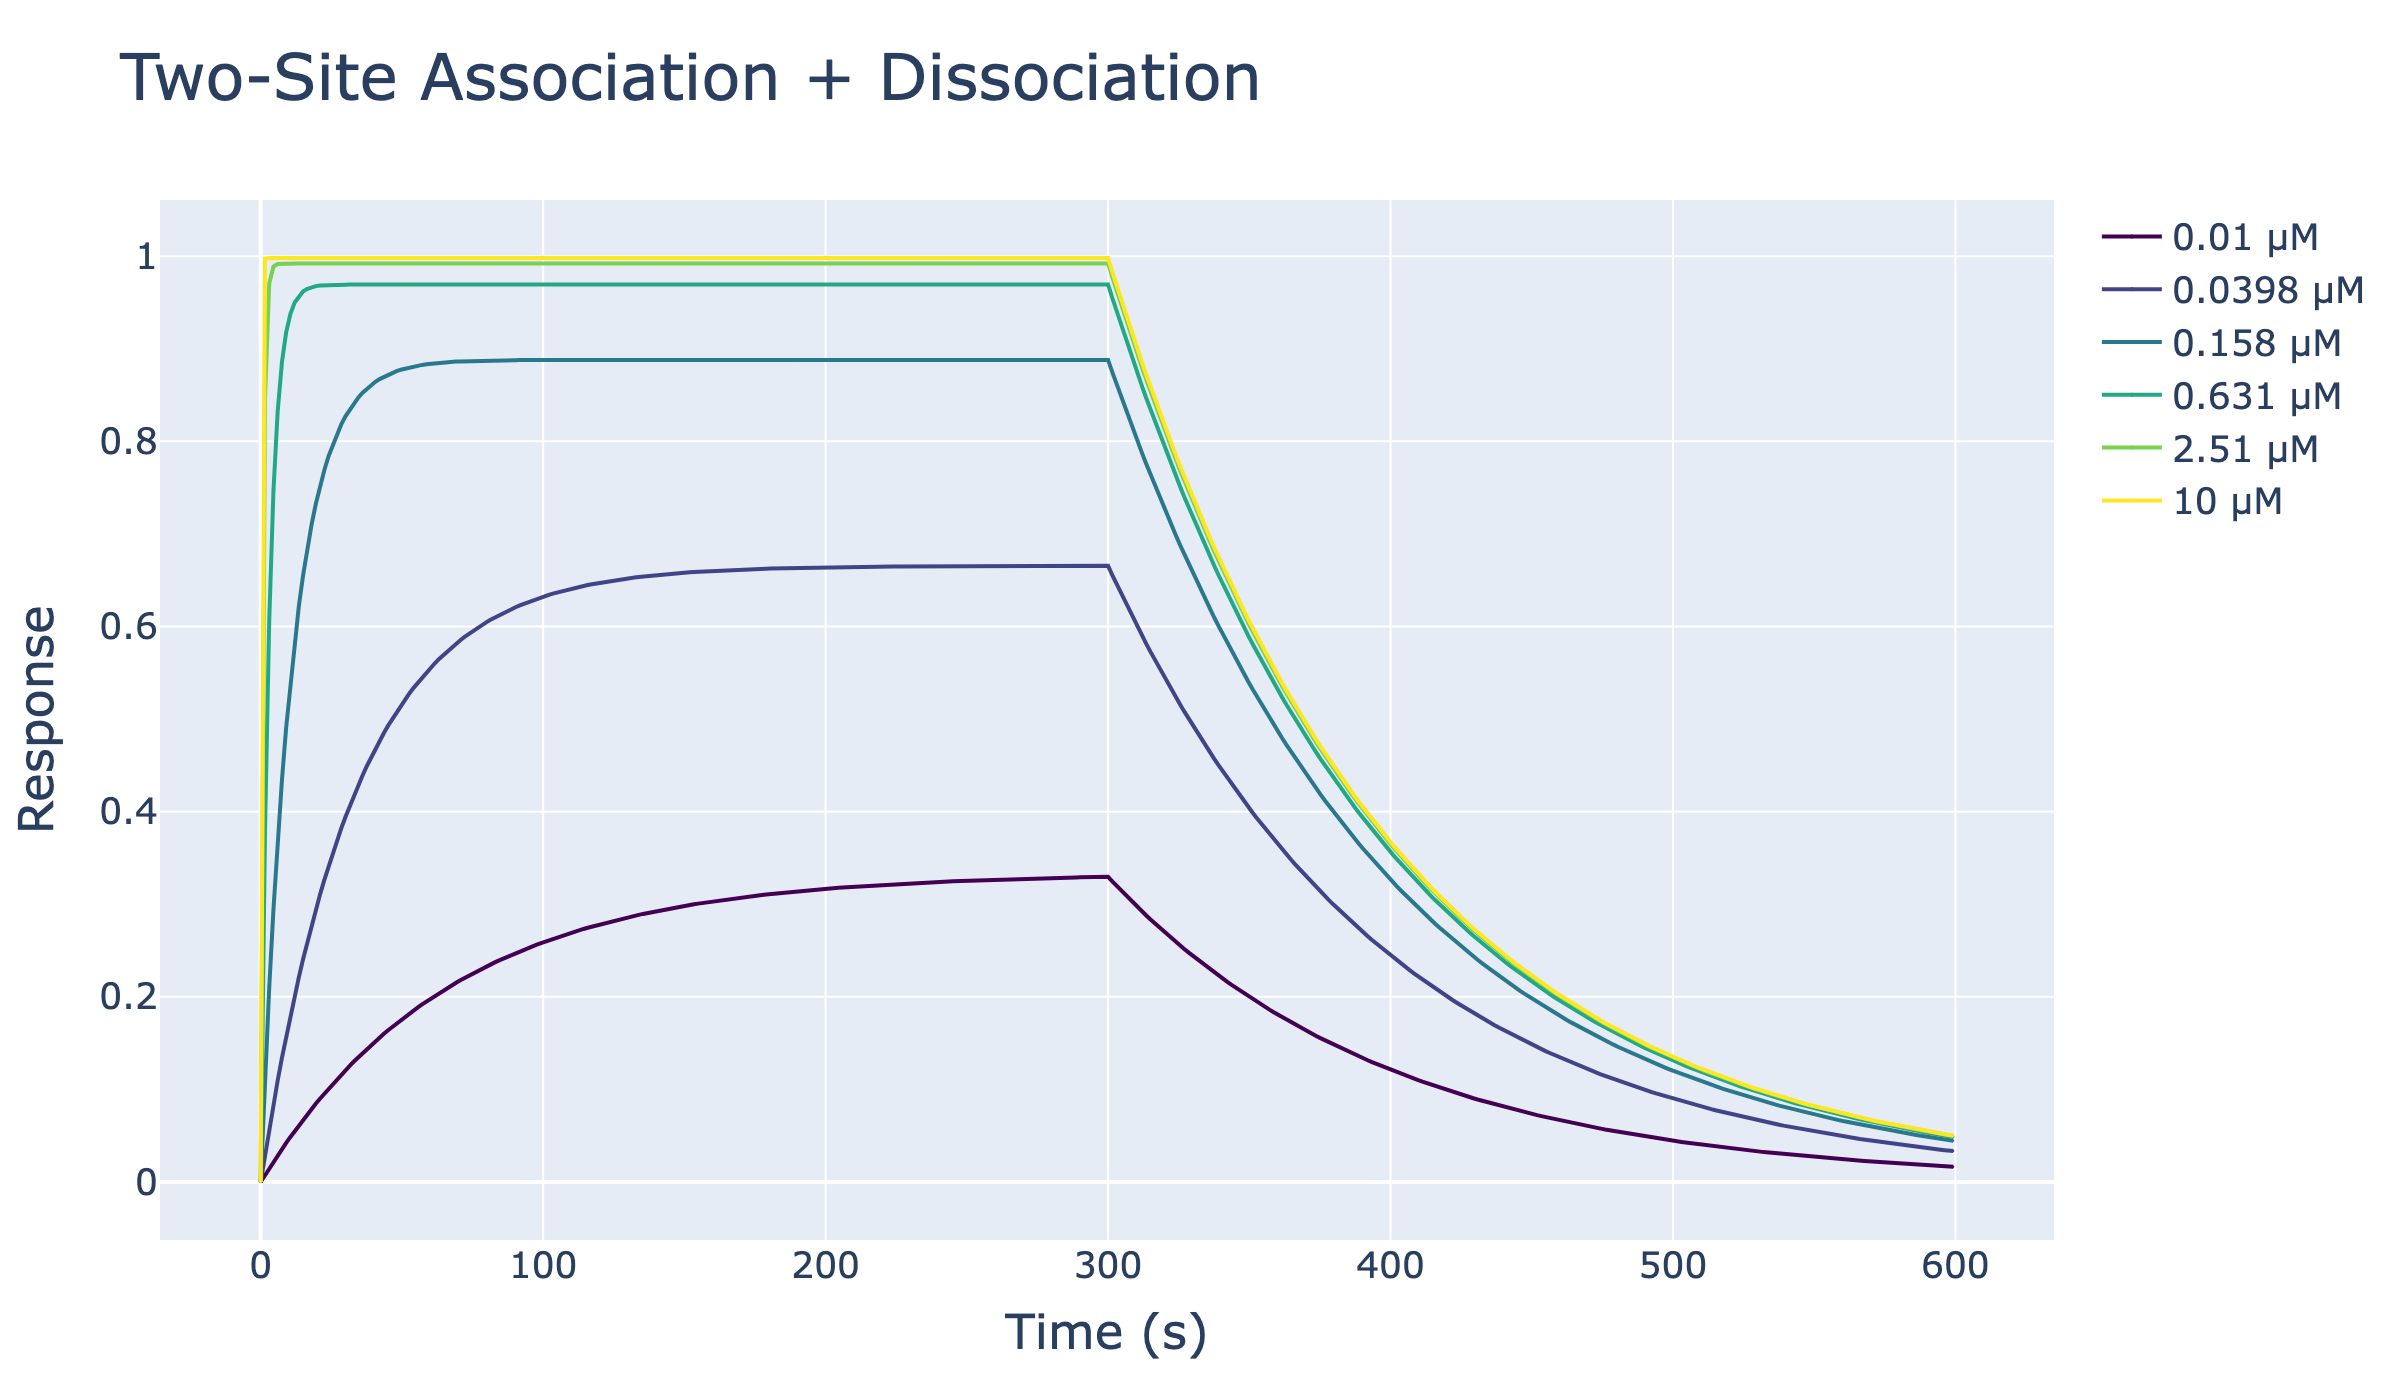

In [10]:
fig = plot_traces(
    xs=combined_xs,
    ys=combined_ys,
    legends=legends,
    colors=colors,
    show=show,
    marker_size=1,
    line_width=2,
)

fig.update_layout(
    title={"text": "Two-Site Association + Dissociation", "font": {"size": 32}},
    xaxis_title="Time (s)",
    yaxis_title="Response",
    font={"size": 20},
    legend={"font": {"size": 18}},
)
fig.update_xaxes(title_font={"size": 24}, tickfont={"size": 18})
fig.update_yaxes(title_font={"size": 24}, tickfont={"size": 18})

show_plotly_static(fig)